In [ ]:
import brandtpompe as bp
import pandas as pd

for n in [64, 128]:
    for embedding in ['hilbert', 'raster1', 'raster2']:
        df = pd.read_csv(f'./img_data_{n}_emb_{embedding}.csv')
        for m in [3,4,5,6,7]:
            for tau in [1,2,3]:

                print (f'Ordinal distribution for n={n}, embedding={embedding}, m={m}, tau={tau}')

                output_path = f'./odp/{n}/{embedding}/m_{m}/tau_{tau}/'

                df_bp = bp.ordinal_distribution_save(df, m=m, tau=tau,output_path=output_path, verbose=False)

                file_name = f'./odp/img_data_{n}_emb_{embedding}_m{m}_tau{tau}.csv'

                df_bp.to_csv(file_name, index=False)
                print (f'Ordinal distribution saved to {file_name}')



In [ ]:
import brandtpompe as bp
import pandas as pd
import numpy as np
import os

color_map = {
    'aluminium_foil': '#ff1493',  # Deep Pink
    'brown_bread': '#3a5fcd',  # Royal Blue
    'corduroy': '#32cd32',  # Lime Green
    'cotton': "#ffe731",  # Orange
    'cracker': '#8a2be2',  # Blue Violet
    'linen': '#00ced1',  # Dark Turquoise
    'orange_peel': "#ff9500",  # Orange Red
    'sandpaper': '#2e8b57',  # Sea Green
    'sponge': '#ff6347',  # Tomato
    'styrofoam': '#1e90ff'  # Dodger Blue   
}

main_path = 'odp'
limy = [0,0,0,1,1,0.2,0.03,0.015]

for n in [64, 128]:
    for embedding in ['hilbert', 'raster1', 'raster2']:
        for m in [3,4,5,6,7]:
            for tau in [1,2,3]:
                path=f'./{main_path}/{n}/{embedding}/m_{m}/tau_{tau}/'
                df = pd.read_csv(f'./odp/img_data_{n}_emb_{embedding}_m{m}_tau{tau}.csv')
                for index, row in df.iterrows():
                    image_file = row['image_file']
                    image_id = row['image_id']
                    image_class = row['class']

                    class_name = image_class.replace('_','-')
                    
                    file_name =f'odp_{class_name}_{image_id}_m{m}_tau{tau}.npy'

                    save_path=f'./{main_path}_plot/{n}/{embedding}/m_{m}/tau_{tau}/'
                    file_name_png =f'{main_path}_plot_{class_name}_{image_id}_m{m}_tau{tau}.png'

                    descrip=f' Embedding: {embedding}, Tamaño: {n}x{n}, Imagen: {image_id}, Clase: {class_name}'

                    #cargar la distribución ordinal desde el archivo numpy
                    p = np.load(os.path.join(path, file_name), allow_pickle=True).item()['probabilities']

                    color = color_map[image_class]

                    bp.ordinal_probability_plot (p=p, m=m, tau=tau, descrip=descrip, color=color, save_path=save_path, file_name=file_name_png, lim_y=(0,limy[m]))





In [ ]:
import brandtpompe as bp
import pandas as pd
import numpy as np
import os

dictionary_entropy_parameter = {
    'shannon': [0],
    'renyi': [0.2, 0.4, 0.8, 1, 2, 4, 8],
    'tsallis': [0.2, 0.4, 0.8, 1, 2, 4, 8]
}

for n in [64, 128]:
    for embedding in ['hilbert', 'raster1', 'raster2']:
        for m in [3,4,5,6,7]:
            for tau in [1,2,3]:
                for entropy_type in ['shannon', 'renyi', 'tsallis']:
                    for entropy_parameter in dictionary_entropy_parameter[entropy_type]:
                        entropy_parameter_str = str(entropy_parameter).replace('.','-')

                        df = pd.read_csv(f'./odp/img_data_{n}_emb_{embedding}_m{m}_tau{tau}.csv')

                        print(f'Processing {n}, {embedding}, m={m}, tau={tau}, entropy_type={entropy_type}, entropy_parameter={entropy_parameter}')

                        df_entropy_complexity = bp.entropy_complexity_save(df, entropy_type=entropy_type, entropy_parameter=entropy_parameter, verbose=True)

                        path_results = f'./results/{n}/{embedding}/m_{m}/tau_{tau}/'
                        file_name_results = f'entropy_complexity_{embedding}_m{m}_tau{tau}_{entropy_type}_{entropy_parameter_str}.csv'

                        if not os.path.exists(path_results):
                            os.makedirs(path_results)

                        df_entropy_complexity.to_csv(os.path.join(path_results, file_name_results), index=False)
                        print (f'Entropy and complexity results saved to {os.path.join(path_results, file_name_results)}')





In [11]:
'''

Processing 64, hilbert, m=3, tau=1, entropy_type=shannon, entropy_parameter=0
Calculando entropía y complejidad para la imagen: ./img/64/aluminium_foil/00001.png - Clase: aluminium_foil - Método: hilbert
Archivo cargado: ./odp/64/hilbert/m_3/tau_1/odp_aluminium-foil_1_m3_tau1.npy - Tipo de entropía: shannon - Parámetro: 0

'''

import numpy as np


data = np.load('./odp/64/hilbert/m_3/tau_1/odp_aluminium-foil_1_m3_tau1.npy', allow_pickle=True)

print(data)

[0.29653151 0.11675623 0.11504641 0.13287738 0.13116756 0.20762091]


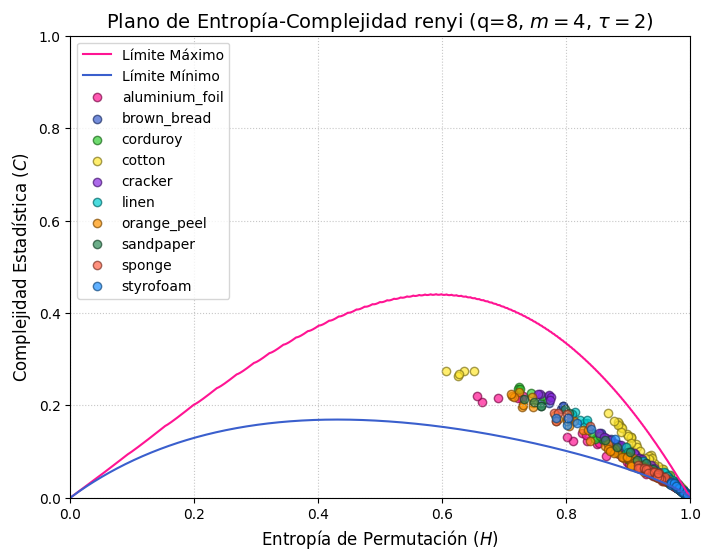

In [ ]:
import brandtpompe as bp
import pandas as pd


color_map = {
    'aluminium_foil': '#ff1493',  # Deep Pink
    'brown_bread': '#3a5fcd',  # Royal Blue
    'corduroy': '#32cd32',  # Lime Green
    'cotton': "#ffe731",  # Orange
    'cracker': '#8a2be2',  # Blue Violet
    'linen': '#00ced1',  # Dark Turquoise
    'orange_peel': "#ff9500",  # Orange Red
    'sandpaper': '#2e8b57',  # Sea Green
    'sponge': '#ff6347',  # Tomato
    'styrofoam': '#1e90ff'  # Dodger Blue   
}

classes=[] #['cotton', 'orange_peel']  # Classes a mostrar en el gráfico
top = -1

xlim=(0,1)
ylim=(0,1)

n=128
embedding='hilbert'
m=3
tau=1
sample= 1 #1+ 84+
class_name = 'aluminium-foil'  #'aluminium-foil' 'brown-bread'
main_path = 'odp'
entropy_type='shannon' #'shannon', 'renyi', 'tsallis'
entropy_parameter=0
entropy_parameter_str = str(entropy_parameter).replace('.','-')

df = pd.read_csv(f'./results/{n}/{embedding}/m_{m}/tau_{tau}/entropy_complexity_{embedding}_m{m}_tau{tau}_{entropy_type}_{entropy_parameter_str}.csv')

#hc_max = opp.maximum_complexity_entropy_tsallis(dx=m, q=entropy_parameter)
#hc_min = opp.minimum_complexity_entropy_tsallis(dx=m, q=entropy_parameter)

#print (f'hc_max: {hc_max}, hc_min: {hc_min}')

bp.entropy_complexity_plot (df, descrip=None, color_map=color_map, save_path=None, file_name= None, lim=(0,1), hc_max=hc_max, hc_min=hc_min, classes=classes, images=[], top=top, legend=True, xlim=xlim, ylim=ylim)




In [ ]:
import brandtpompe as bp
import pandas as pd
import os

from ordpy.ordpy import ordpy

from ordpy import ordpy

color_map = {
    'aluminium_foil': '#ff1493',  # Deep Pink
    'brown_bread': '#3a5fcd',  # Royal Blue
    'corduroy': '#32cd32',  # Lime Green
    'cotton': "#ffe731",  # Orange
    'cracker': '#8a2be2',  # Blue Violet
    'linen': '#00ced1',  # Dark Turquoise
    'orange_peel': "#ff9500",  # Orange Red
    'sandpaper': '#2e8b57',  # Sea Green
    'sponge': '#ff6347',  # Tomato
    'styrofoam': '#1e90ff'  # Dodger Blue   
}

dictionary_entropy_parameter = {
    'shannon': [0],
    'renyi': [0.2, 0.4, 0.8, 1, 2, 4, 8],
    'tsallis': [0.2, 0.4, 0.8, 1, 2, 4, 8]
}

classes=[] #['cotton', 'orange_peel']  # Classes a mostrar en el gráfico
top = -1
xlim=(0,1)
ylim=(0,1)
main_path = 'results'

# Se crea una lista hc_maxs y hc_mins, según los posibles valores de m 
hc_maxs = [[],[],[],[],[],[],[],[]]
hc_mins = [[],[],[],[],[],[],[],[]]
for m in [3,4,5,6,7]:
    print (f'Calculating hc_max and hc_min for m={m}')
    hc_maxs[m] = ordpy.maximum_complexity_entropy(dx=m, m=100)
    hc_mins[m] = ordpy.minimum_complexity_entropy(dx=m)

print (f'hc_maxs and hc_mins created.')

for n in [64, 128]:
    for embedding in ['hilbert', 'raster1', 'raster2']:
        for m in [3,4,5,6,7]:
            for tau in [1,2,3]:
                for entropy_type in ['shannon', 'renyi', 'tsallis']:
                    for entropy_parameter in dictionary_entropy_parameter[entropy_type]:
                        entropy_parameter_str = str(entropy_parameter).replace('.','-')

                        path=f'./{main_path}/{n}/{embedding}/m_{m}/tau_{tau}/'
                        file_name = f'entropy_complexity_{embedding}_m{m}_tau{tau}_{entropy_type}_{entropy_parameter_str}.csv'

                        curve_path = f'./{main_path}_plot/{n}/{embedding}/m_{m}/tau_{tau}/'
                        curve_file_name = f'entropy_complexity_{embedding}_m{m}_tau{tau}_{entropy_type}_{entropy_parameter_str}.png'

                        df = pd.read_csv(os.path.join(path, file_name))

                        print(f'Processing {n}, {embedding}, m={m}, tau={tau}, entropy_type={entropy_type}, entropy_parameter={entropy_parameter}')

                        descrip = f'Embedding: {embedding}, Tamaño: {n}x{n}'

                        bp.entropy_complexity_plot (df, descrip=descrip, color_map=color_map, save_path=curve_path, file_name= curve_file_name, lim=(0,1), hc_max=hc_maxs[m], hc_min=hc_mins[m], classes=classes, images=[], top=top, legend=True, xlim=xlim, ylim=ylim)

